In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [61]:
df = pd.read_csv(r"C:\Users\Amey\Downloads\archive (5)\insurance.csv")

In [62]:
print(df['sex'].unique())
print(df['smoker'].unique())

['female' 'male']
['yes' 'no']


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [64]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


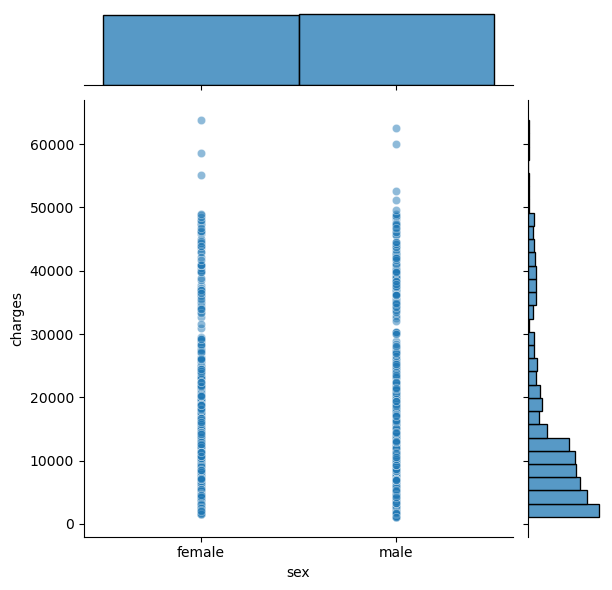

In [65]:
sns.jointplot(x="sex",y = "charges",data= df, alpha = 0.5)

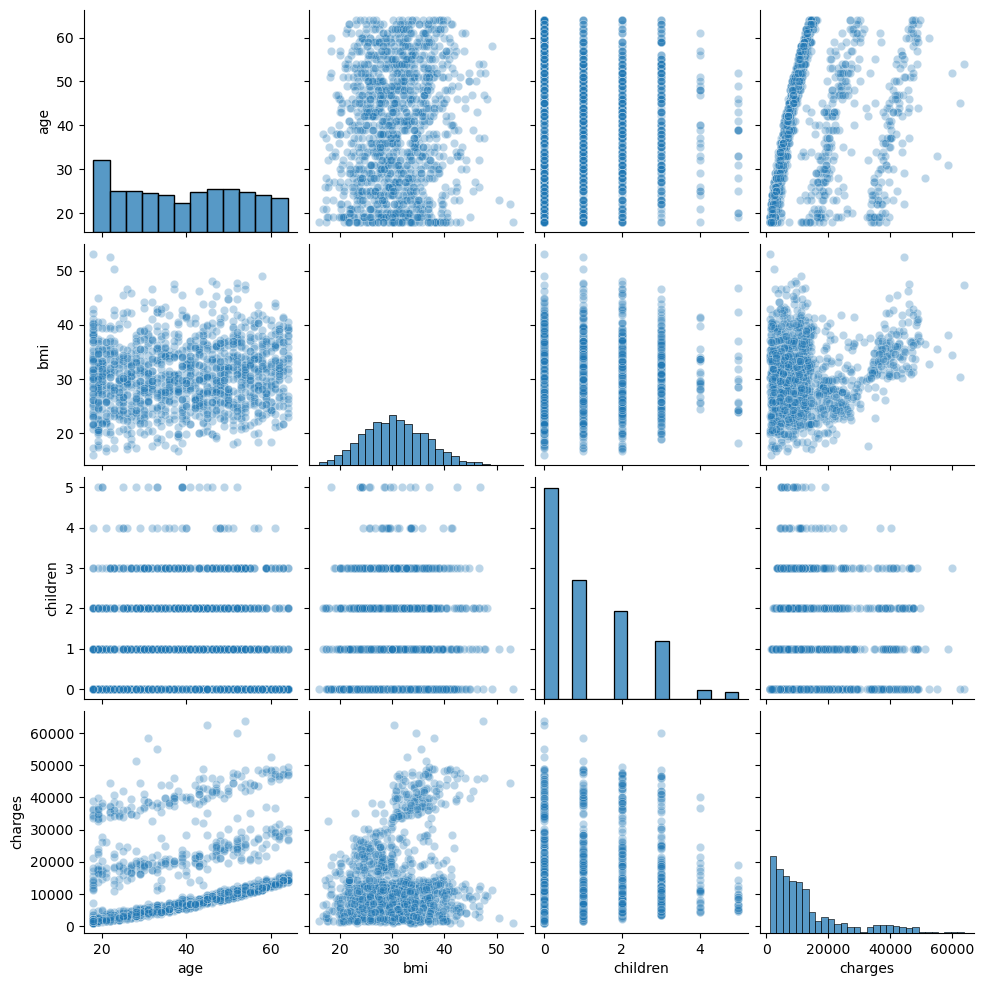

In [66]:
sns.pairplot(df, kind='scatter',plot_kws={'alpha':0.3})

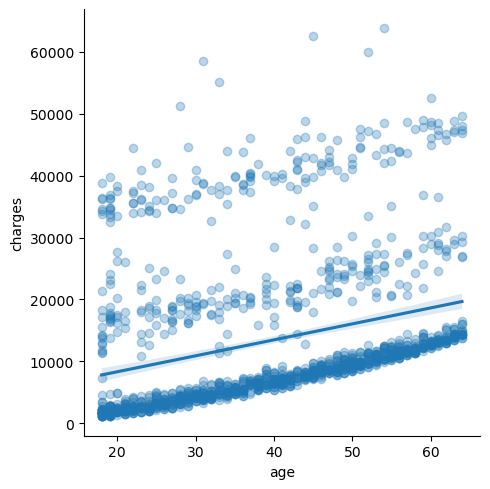

In [67]:
sns.lmplot(x='age' , 
           y= 'charges',
            data=df ,
            scatter_kws={'alpha': 0.3})

In [68]:
print(df['sex'].unique())
print(df['smoker'].unique())


['female' 'male']
['yes' 'no']


In [69]:
print(df.columns)

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')


In [70]:
df['sex'] = df['sex'].map({
    'female': 0,
    'male': 1
})

df['smoker'] = df['smoker'].map({
    'no': 0,
    'yes': 1
})

In [71]:
print(df['sex'].unique())
print(df['smoker'].unique())

[0 1]
[1 0]


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   int64  
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   int64  
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(4), object(1)
memory usage: 73.3+ KB


In [73]:
from sklearn.model_selection import train_test_split

In [74]:
X = df[['sex','age','bmi','children','smoker',]]
y = df['charges']

In [75]:
X_train , X_test , y_train , y_test = train_test_split(X,
                                                       y,
                                                       random_state=42,
                                                        test_size=0.2)

In [76]:
from sklearn.linear_model import LinearRegression

In [77]:
lm = LinearRegression()

In [78]:
lm.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [79]:
X_test

,sex,age,bmi,children,smoker
764,0,45,25.175,2,0
887,0,36,30.020,0,0
890,0,64,26.885,0,1
1293,1,46,25.745,3,0
259,1,19,31.920,0,1
...,...,...,...,...,...
109,1,63,35.090,0,1
575,0,58,27.170,0,0
535,1,38,28.025,1,0
543,0,54,47.410,0,1


In [80]:
lm.coef_

array([-7.95178837e+00,  2.57068962e+02,  3.27533514e+02,  4.27254431e+02,
        2.36539033e+04])

In [81]:
cdf = pd.DataFrame(lm.coef_,X.columns, columns=['Coef'])
print(cdf)

                  Coef
sex          -7.951788
age         257.068962
bmi         327.533514
children    427.254431
smoker    23653.903315


In [83]:
predictions = lm.predict(X_test)
predictions

array([ 8554.81711589,  6973.58746745, 36798.60416104,  9417.88282303,
       26871.68031081, 11097.38383938,   145.27608963, 16746.1683771 ,
         747.53414191, 11153.67590722, 28518.15016561,  9292.18345421,
        5460.51975119, 38510.48013003, 40359.30938604, 37223.40538064,
       15316.56711945, 36047.50032223,  9326.29049907, 31400.1559532 ,
        4269.64414373, 10464.66374097,  2719.9260555 ,  6579.53742551,
       11232.00255515, 12472.06793446, 14807.11281089,  6066.19283362,
        9535.69029723,  2377.6983797 ,  9475.05690885, 12963.23366722,
        4706.09057393,  3414.674504  ,  4815.64981654, 12484.17176954,
        2359.13614479,  9161.02061228, 33238.67621442, 32743.41702445,
        4274.58967205,  4229.5442107 , 14435.36485176, 11384.66898976,
        8925.70468583, 12480.09178788,  5154.45787816,  3554.10047649,
       35649.60942684,  9276.25523701, 15971.35991397,  2552.75200479,
       12162.99980138,  1062.65132285, 13551.43771934, 12103.65505529,
      

Text(0.5, 1.0, 'insurance cost')

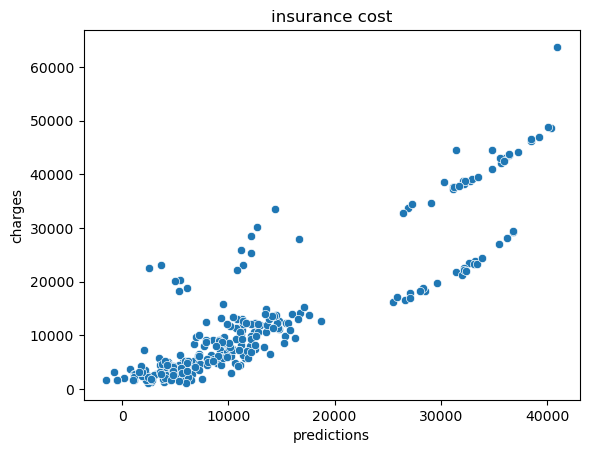

In [84]:
sns.scatterplot(x=predictions, y=y_test)
plt.xlabel("predictions")
plt.title("insurance cost")

In [88]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
import math


In [89]:
print( "MAE:" ,mean_absolute_error(y_test,predictions))
print("MSE:" , mean_squared_error(y_test,predictions))
print("RMSE:" , math.sqrt(mean_squared_error(y_test,predictions))) 

MAE: 4213.484797807143
MSE: 33979257.05080821
RMSE: 5829.17293025419


In [90]:
residuals = y_test - predictions
residuals

764       540.251134
887     -1701.411667
890     -7467.621011
1293     -115.989273
259      6878.611489
            ...     
109      7834.536211
575       527.264176
535     -1186.471925
543     22819.888106
846     -2753.265419
Name: charges, Length: 268, dtype: float64

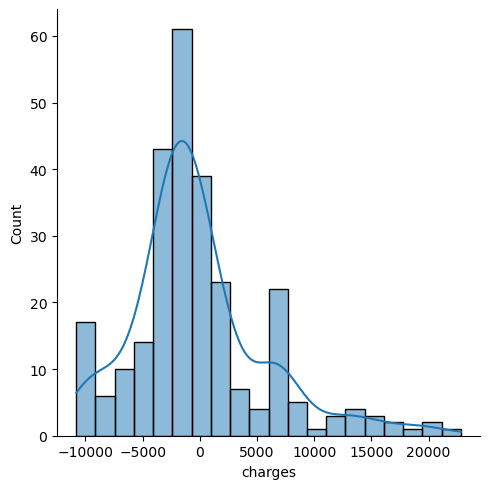

In [91]:
sns.displot(residuals, bins = 20 , kde = True)

<function matplotlib.pyplot.show(close=None, block=None)>

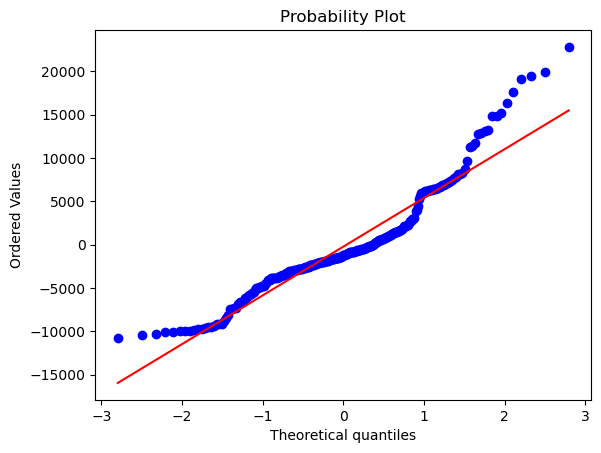

In [93]:
import pylab
import scipy.stats as stats

stats.probplot(
    residuals,
    dist = "norm",
    plot = pylab
)

pylab.show